In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

profit_loss = pd.read_csv("../data/clean/profitandloss.csv")
balance_sheet = pd.read_csv("../data/clean/balancesheet.csv")
cashflow = pd.read_csv("../data/clean/cashflow.csv")
companies = pd.read_csv("../data/clean/companies.csv")

print("Profit Loss:", profit_loss.shape)
print("Balance Sheet:", balance_sheet.shape)
print("Cash Flow:", cashflow.shape)
print("Companies:", companies.shape)

Profit Loss: (1276, 15)
Balance Sheet: (1312, 13)
Cash Flow: (1187, 7)
Companies: (100, 12)


In [17]:
profit_loss["sales"] = pd.to_numeric(
    profit_loss["sales"],
    errors="coerce"
)

top_revenue = (
    profit_loss.groupby("company_id")["sales"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

top_revenue

company_id
RELIANCE      939838
LICI          896106
IOC           841756
ONGC          658694
BPCL          473187
SBIN          469625
TATAMOTORS    440061
HDFCBANK      329022
TCS           252082
TATASTEEL     243959
Name: sales, dtype: int64

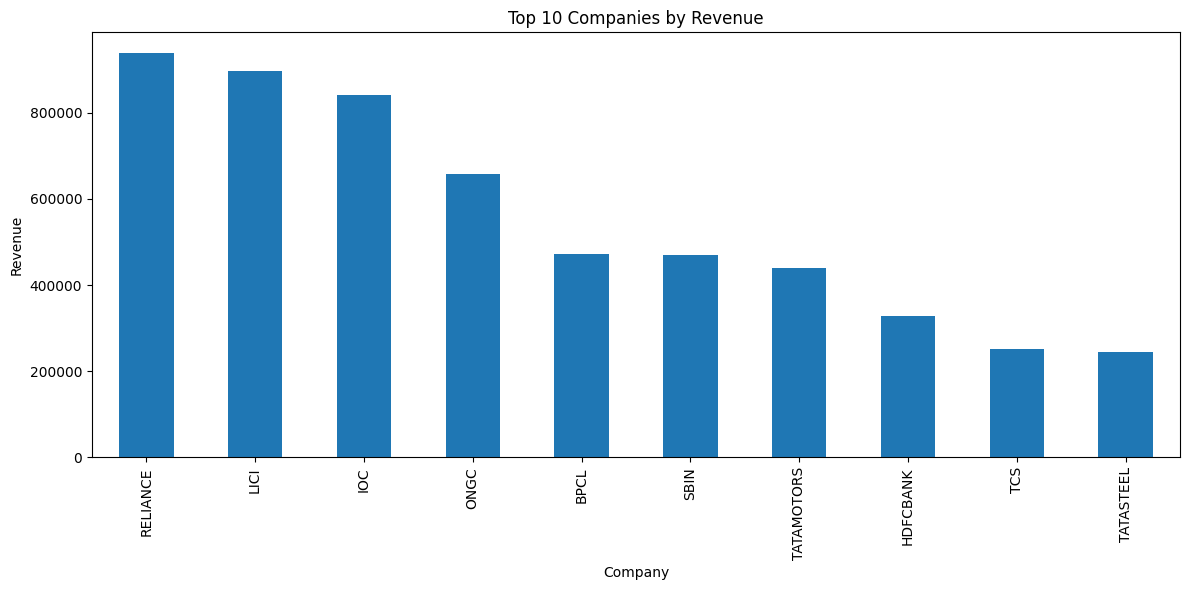

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top_revenue.plot(kind="bar")

plt.title("Top 10 Companies by Revenue")
plt.xlabel("Company")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [19]:
profit_loss["net_profit"] = pd.to_numeric(
    profit_loss["net_profit"],
    errors="coerce"
)

top_profit = (
    profit_loss.groupby("company_id")["net_profit"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

top_profit

company_id
RELIANCE     79941
SBIN         74461
HDFCBANK     72168
ONGC         57101
ICICIBANK    52416
TCS          49006
IOC          43161
TATASTEEL    41749
LICI         41468
COALINDIA    37369
Name: net_profit, dtype: int64

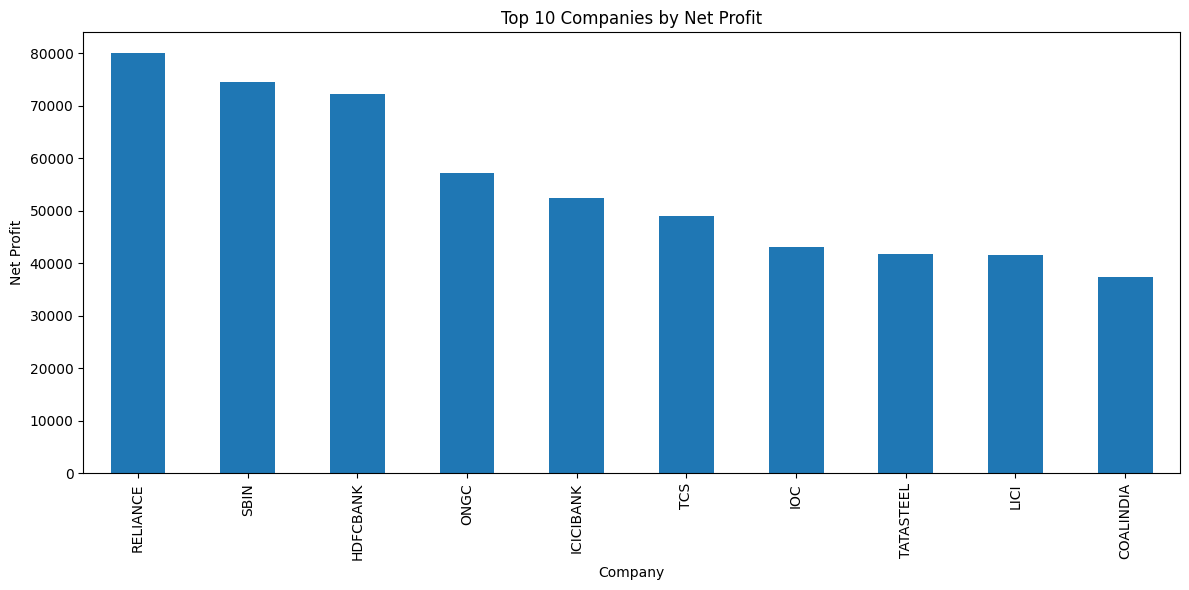

In [20]:
plt.figure(figsize=(12,6))

top_profit.plot(kind="bar")

plt.title("Top 10 Companies by Net Profit")
plt.xlabel("Company")
plt.ylabel("Net Profit")

plt.tight_layout()

plt.show()

In [21]:
yearly_revenue = (
    profit_loss.groupby("year")["sales"]
    .sum()
    .sort_index()
)

yearly_revenue

year
Dec 2012          28251
Dec 2013          35944
Dec 2014          31050
Dec 2015          21006
Dec 2016          33096
Dec 2017          37623
Dec 2018          42438
Dec 2019          46603
Dec 2020          44316
Dec 2021          52529
Dec 2022          30070
Dec 2023          35169
Jun 2013          30999
Jun 2014          37859
Jun 2015          42960
Mar 2011           2173
Mar 2012           2954
Mar 2013        3361597
Mar 2014        3844320
Mar 2015        3987780
Mar 2016        3726303
Mar 2016 9m       36650
Mar 2017        4191668
Mar 2018        4709631
Mar 2019        6223131
Mar 2020        6261780
Mar 2021        6211774
Mar 2022        7788791
Mar 2023        9557429
Mar 2023 15       38937
Mar 2024       10487581
Sep 2011          11955
Sep 2014          10678
Sep 2015          10563
Sep 2016          10837
Sep 2017          11065
Sep 2018          12795
Sep 2019          13084
Sep 2020           9946
Sep 2021          13198
Sep 2022          16138
Sep 2023   

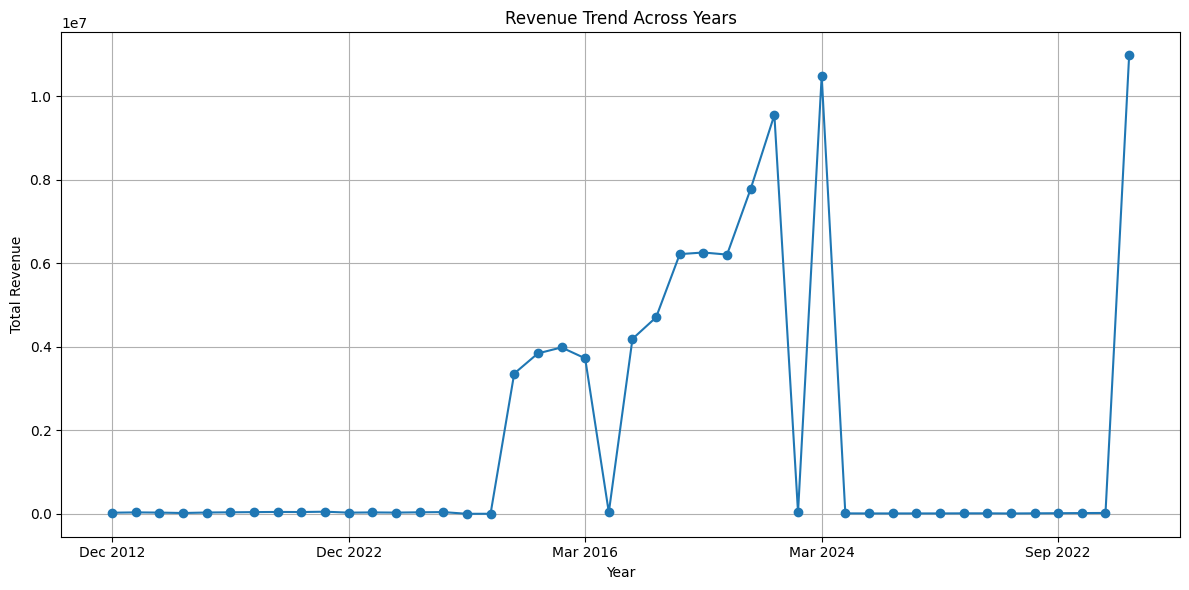

In [22]:
plt.figure(figsize=(12,6))

yearly_revenue.plot(marker="o")

plt.title("Revenue Trend Across Years")
plt.xlabel("Year")
plt.ylabel("Total Revenue")

plt.grid(True)

plt.tight_layout()

plt.show()

In [23]:
import re

def extract_year(value):

    value = str(value)

    if value.upper() == "TTM":
        return "TTM"

    match = re.search(r"(20\d{2})", value)

    if match:
        return match.group(1)

    match = re.search(r"-(\d{2})", value)

    if match:
        return "20" + match.group(1)

    return None


profit_loss["clean_year"] = (
    profit_loss["year"]
    .apply(extract_year)
)

profit_loss[
    ["year", "clean_year"]
].head(20)

,year,clean_year
0,Dec 2012,2012
1,Mar 2014,2014
2,Mar 2015,2015
3,Mar 2016,2016
4,Mar 2017,2017
5,Mar 2018,2018
6,Mar 2019,2019
7,Mar 2020,2020
8,Mar 2021,2021
9,Mar 2022,2022


In [24]:
yearly_revenue_clean = (
    profit_loss[
        profit_loss["clean_year"] != "TTM"
    ]
    .groupby("clean_year")["sales"]
    .sum()
)

yearly_revenue_clean

clean_year
2011       14128
2012       31205
2013     3428540
2014     3923907
2015     4062309
2016     3806886
2017     4240356
2018     4764864
2019     6282818
2020     6316042
2021     6277501
2022     7834999
2023     9651089
2024    10509821
Name: sales, dtype: int64

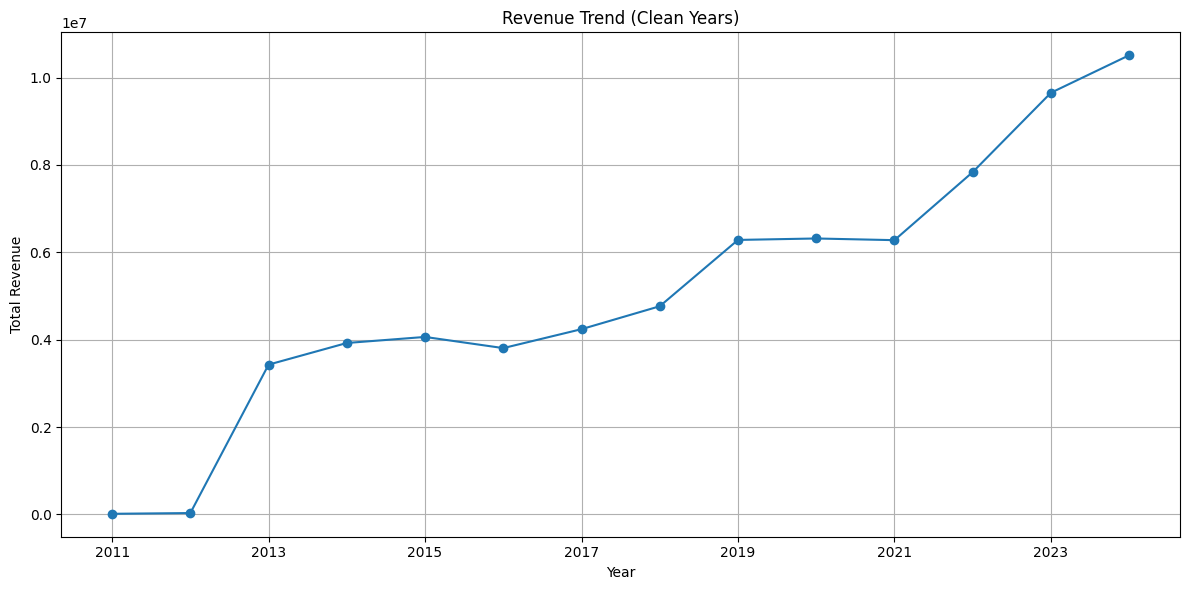

In [25]:
plt.figure(figsize=(12,6))

yearly_revenue_clean.plot(
    kind="line",
    marker="o"
)

plt.title("Revenue Trend (Clean Years)")
plt.xlabel("Year")
plt.ylabel("Total Revenue")

plt.grid(True)

plt.tight_layout()

plt.show()

In [26]:
sector_map = pd.read_csv("../data/sector_mapping.csv")

sector_map.head()

,company_id,sector
0,TCS,IT
1,INFY,IT
2,WIPRO,IT
3,HCLTECH,IT
4,TECHM,IT


In [27]:
profit_sector = profit_loss.merge(
    sector_map,
    on="company_id",
    how="left"
)

profit_sector.head()

,id,company_id,year,sales,expenses,operating_profit,opm_percentage,other_income,interest,depreciation,profit_before_tax,tax_percentage,net_profit,eps,dividend_payout,clean_year,sector
0,61,ABB,Dec 2012,1653,1451,202.0,12.0,33,0,19,215,33.0,145,68.0,25.0,2012,NaN
1,62,ABB,Mar 2014,2276,2009,267.0,12.0,49,0,22,295,33.0,198,93.0,25.0,2014,NaN
2,63,ABB,Mar 2015,2289,1977,312.0,14.0,48,0,15,344,34.0,229,108.0,29.0,2015,NaN
3,64,ABB,Mar 2016,2614,2250,365.0,14.0,50,3,14,398,36.0,255,120.0,29.0,2016,NaN
4,65,ABB,Mar 2017,2903,2505,398.0,14.0,57,2,16,436,37.0,277,130.0,31.0,2017,NaN


In [29]:
sector_revenue = (
    profit_sector.groupby("sector")["sales"]
    .sum()
    .sort_values(ascending=False)
)

sector_revenue

sector
Energy        11934585
Banking        7540751
IT             5276707
Power          2281361
Insurance      1354301
NBFC            945230
Cement          826317
Pharma          659688
Paint           277577
Healthcare      137131
Name: sales, dtype: int64

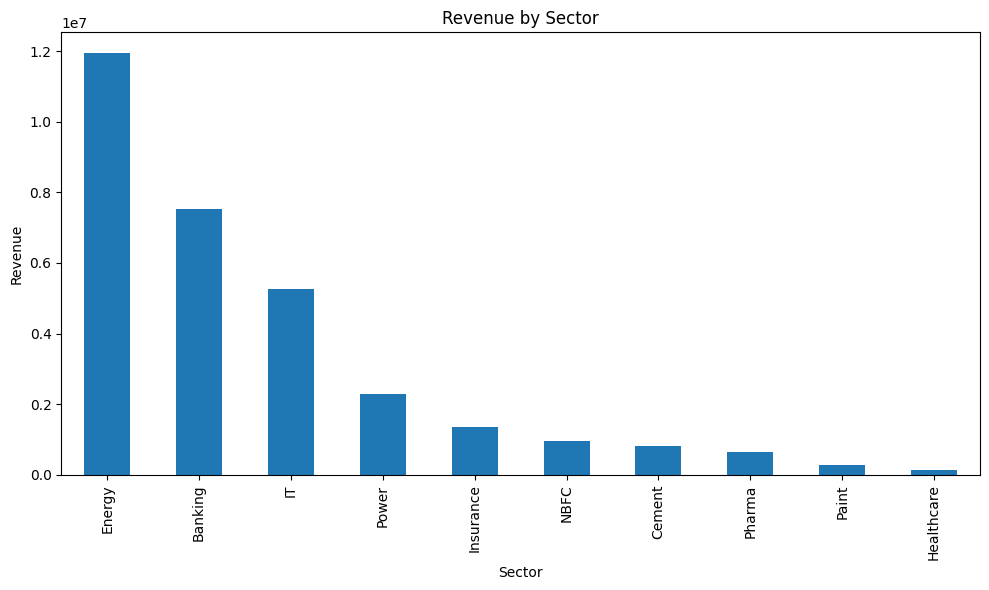

In [30]:
plt.figure(figsize=(10,6))

sector_revenue.plot(kind="bar")

plt.title("Revenue by Sector")
plt.xlabel("Sector")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [31]:
profit_loss["sales"] = pd.to_numeric(
    profit_loss["sales"],
    errors="coerce"
)

profit_loss["net_profit"] = pd.to_numeric(
    profit_loss["net_profit"],
    errors="coerce"
)

profit_loss["net_profit_margin"] = (
    profit_loss["net_profit"]
    / profit_loss["sales"]
) * 100

In [32]:
company_margin = (
    profit_loss.groupby("company_id")
    ["net_profit_margin"]
    .mean()
    .sort_values(ascending=False)
)

company_margin.head(10)

company_id
BAJAJHLDNG    591.936837
NAUKRI         84.360082
JIOFIN         79.022768
ADANIPORTS     35.935293
NHPC           35.890221
POWERGRID      31.307839
KOTAKBANK      26.827546
ITC            26.582386
DIVISLAB       26.459194
RECLTD         25.084538
Name: net_profit_margin, dtype: float64

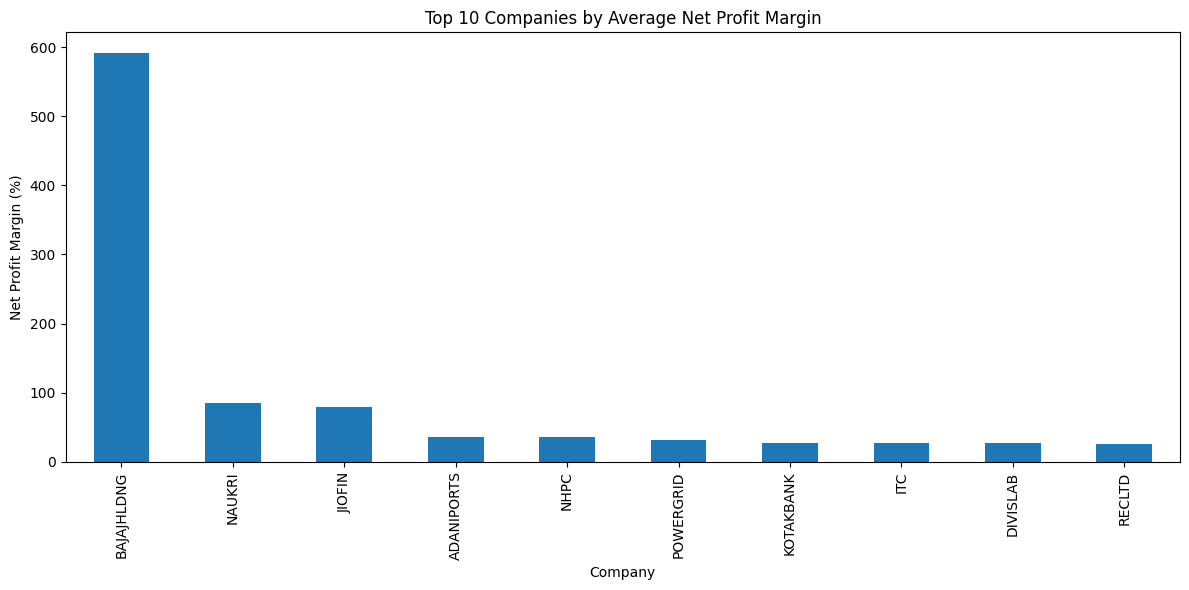

In [33]:
top_margin = company_margin.head(10)

plt.figure(figsize=(12,6))

top_margin.plot(kind="bar")

plt.title("Top 10 Companies by Average Net Profit Margin")
plt.xlabel("Company")
plt.ylabel("Net Profit Margin (%)")

plt.tight_layout()

plt.show()

In [34]:
de_ratio = pd.read_csv(
    "../data/clean/balancesheet_with_de_ratio.csv"
)

de_ratio.head()

,id,company_id,year,equity_capital,reserves,borrowings,other_liabilities,total_liabilities,fixed_assets,cwip,investments,other_asset,total_assets,debt_to_equity
0,136,ABB,Dec 2012,21.0,626,0,260,907,109,1,0,798,907,0.0
1,137,ABB,Mar 2014,21.0,767,0,351,1139,98,1,0,1040,1139,0.0
2,138,ABB,Mar 2015,21.0,916,0,436,1374,96,4,0,1274,1374,0.0
3,139,ABB,Mar 2016,21.0,1174,0,421,1616,108,3,0,1505,1616,0.0
4,140,ABB,Mar 2017,21.0,1366,0,679,2066,110,6,0,1950,2066,0.0


In [35]:
company_de = (
    de_ratio.groupby("company_id")
    ["debt_to_equity"]
    .mean()
    .sort_values(ascending=False)
)

company_de.head(10)

company_id
LICI          83.643255
UNIONBANK     16.133102
CANBK         15.716222
BANKBARODA    14.142869
ADANIPOWER    10.188930
AXISBANK       9.004988
IRFC           8.573980
PFC            8.379948
ADANIGREEN     8.294498
PNB            8.136311
Name: debt_to_equity, dtype: float64

In [36]:
company_de.head(10)

company_id
LICI          83.643255
UNIONBANK     16.133102
CANBK         15.716222
BANKBARODA    14.142869
ADANIPOWER    10.188930
AXISBANK       9.004988
IRFC           8.573980
PFC            8.379948
ADANIGREEN     8.294498
PNB            8.136311
Name: debt_to_equity, dtype: float64

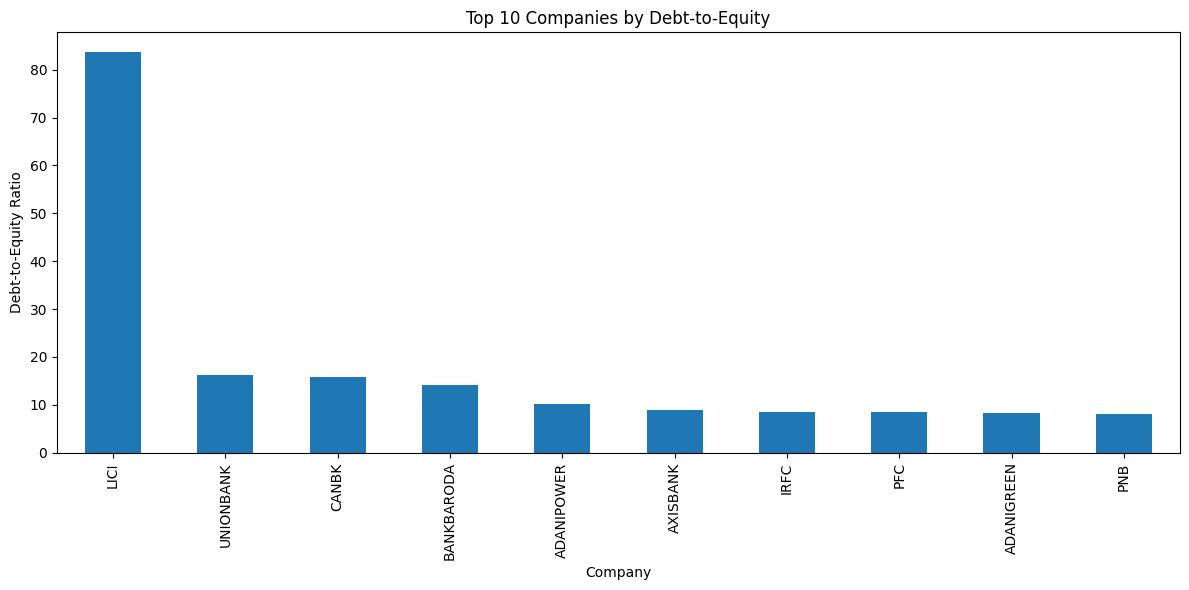

In [37]:
top_de = company_de.head(10)

plt.figure(figsize=(12,6))

top_de.plot(kind="bar")

plt.title("Top 10 Companies by Debt-to-Equity")
plt.xlabel("Company")
plt.ylabel("Debt-to-Equity Ratio")

plt.tight_layout()

plt.show()

In [38]:
margin_df = pd.read_csv(
    "../data/clean/profitandloss_with_margin.csv"
)

de_df = pd.read_csv(
    "../data/clean/balancesheet_with_de_ratio.csv"
)

fcf_df = pd.read_csv(
    "../data/clean/cashflow_with_fcf.csv"
)

interest_df = pd.read_csv(
    "../data/clean/profitandloss_with_interest_coverage.csv"
)

In [39]:
health = pd.DataFrame()

health["profit_margin"] = (
    margin_df.groupby("company_id")
    ["net_profit_margin_pct"]
    .mean()
)

health["de_ratio"] = (
    de_df.groupby("company_id")
    ["debt_to_equity"]
    .mean()
)

health["free_cash_flow"] = (
    fcf_df.groupby("company_id")
    ["free_cash_flow"]
    .mean()
)

health["interest_coverage"] = (
    interest_df.groupby("company_id")
    ["interest_coverage"]
    .mean()
)

health = health.fillna(0)

health.head()

,profit_margin,de_ratio,free_cash_flow,interest_coverage
company_id,,,,
ABB,13.646582,0.019970,56.391304,128.379207
ADANIENSOL,10.199101,3.004722,-205.636364,2.007628
ADANIENT,2.836075,1.777329,-2613.250000,1.811290
ADANIGREEN,1.664185,8.294498,-5144.875000,1.427150
ADANIPORTS,35.935293,1.276000,585.666667,4.348702


In [40]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

health["profit_score"] = scaler.fit_transform(
    health[["profit_margin"]]
)

health["fcf_score"] = scaler.fit_transform(
    health[["free_cash_flow"]]
)

health["interest_score"] = scaler.fit_transform(
    health[["interest_coverage"]]
)

health["de_score"] = 1 - scaler.fit_transform(
    health[["de_ratio"]]
)

health["health_score"] = (
    health["profit_score"] * 0.30 +
    health["fcf_score"] * 0.30 +
    health["interest_score"] * 0.20 +
    health["de_score"] * 0.20
) * 100

health.sort_values(
    "health_score",
    ascending=False
).head(10)

,profit_margin,de_ratio,free_cash_flow,interest_coverage,profit_score,fcf_score,interest_score,de_score,health_score
company_id,,,,,,,,,
BAJAJHLDNG,591.936837,0.001263,686.333333,307.628816,1.000000,0.484957,0.352863,0.999985,71.605682
BAJAJ-AUTO,16.812154,0.023896,2930.750000,2094.670788,0.080568,0.510357,1.000000,0.999714,57.722058
TCS,20.952829,0.043843,26134.166667,342.338073,0.087188,0.772949,0.365432,0.999476,53.102256
INFY,19.879410,0.039648,12539.250000,639.805272,0.085472,0.619096,0.473153,0.999526,50.590621
VEDL,11.805592,1.336842,18595.416667,3.842790,0.072565,0.687633,0.242854,0.984017,47.343353
DIVISLAB,26.459194,0.005900,467.250000,692.814652,0.095991,0.482478,0.492349,0.999929,47.199643
ITC,26.582386,0.003914,9202.833333,280.449420,0.096188,0.581338,0.343021,0.999953,47.185248
SBIN,8.491733,0.000000,15834.333333,-0.303851,0.067267,0.656386,0.241352,1.000000,46.536633
COALINDIA,18.640943,0.079406,13647.583333,12.448090,0.083492,0.631639,0.245970,0.999051,46.354340


In [41]:
def health_label(score):

    if score >= 70:
        return "EXCELLENT"

    elif score >= 55:
        return "GOOD"

    elif score >= 40:
        return "AVERAGE"

    elif score >= 25:
        return "WEAK"

    else:
        return "POOR"


health["health_label"] = (
    health["health_score"]
    .apply(health_label)
)

health.sort_values(
    "health_score",
    ascending=False
).head(20)[
    ["health_score", "health_label"]
]

,health_score,health_label
company_id,,
BAJAJHLDNG,71.605682,EXCELLENT
BAJAJ-AUTO,57.722058,GOOD
TCS,53.102256,AVERAGE
INFY,50.590621,AVERAGE
VEDL,47.343353,AVERAGE
DIVISLAB,47.199643,AVERAGE
ITC,47.185248,AVERAGE
SBIN,46.536633,AVERAGE
COALINDIA,46.354340,AVERAGE


In [42]:
health.reset_index().to_csv(
    "../data/clean/company_health_scores.csv",
    index=False
)

print("Saved company_health_scores.csv")

Saved company_health_scores.csv


# Key Findings

1. Energy sector generated the highest revenue.
2. Banking sector ranked second in revenue contribution.
3. RELIANCE was the top revenue company.
4. RELIANCE also generated the highest net profit.
5. Revenue across the dataset grew significantly from 2013 to 2024.
6. TCS and INFY demonstrated strong profitability and health scores.
7. Debt-to-equity ratios were naturally high for banking and insurance companies.
8. A composite health score was developed using profitability, cash flow, leverage and interest coverage metrics.